## Problem Statement and Objective

The goal of this project is to perform customer segmentation using unsupervised learning (K-Means clustering) on mall customer data. By analyzing customer demographics, income, and spending habits, we aim to group customers into meaningful clusters and suggest targeted marketing strategies for each segment.




**📌 1. Importing Required Libraries**

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**📌 2. Load & Preview the Dataset**

In [1]:
# Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first few rows
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


📌 3. Dataset info & check missing values

In [2]:
# Dataset Info
df.info()

# Check for missing values
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**📌 4. Data Cleaning & Preprocessing**

In [3]:

# Rename columns for consistency
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Drop CustomerID (not useful for clustering)
df_cleaned = df.drop('CustomerID', axis=1)

# Encode Gender: Male = 0, Female = 1
df_cleaned['Gender'] = df_cleaned['Gender'].map({'Male': 0, 'Female': 1})

# Check cleaned dataset
df_cleaned.head()



,Gender,Age,Annual_Income,Spending_Score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


**📌 5. Exploratory Data Analysis (EDA)**

Visualize the distribution of Gender, Age, Annual Income, and Spending Score.


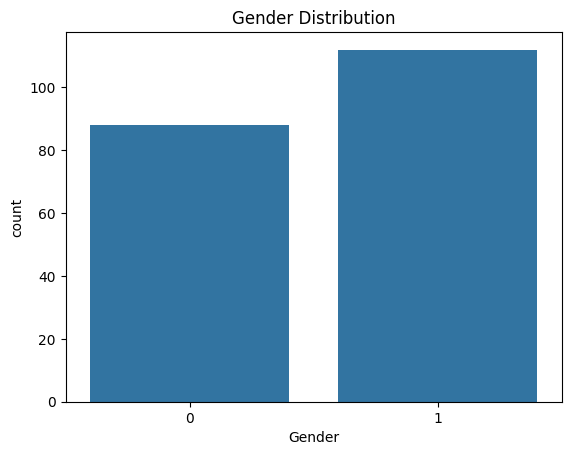

In [5]:
# Gender Distribution
sns.countplot(x='Gender', data=df_cleaned)
plt.title('Gender Distribution')
plt.show()



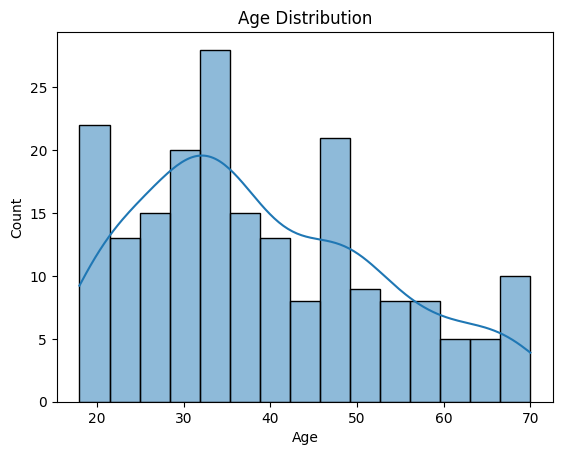

In [6]:
# Age Distribution
sns.histplot(df_cleaned['Age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()



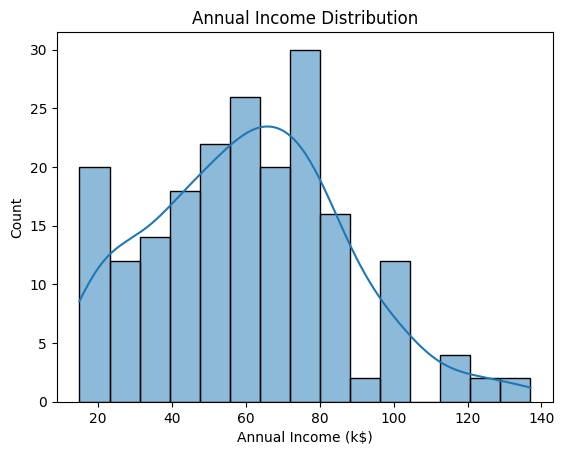

In [7]:
# Annual Income Distribution
sns.histplot(df_cleaned['Annual_Income'], bins=15, kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.show()



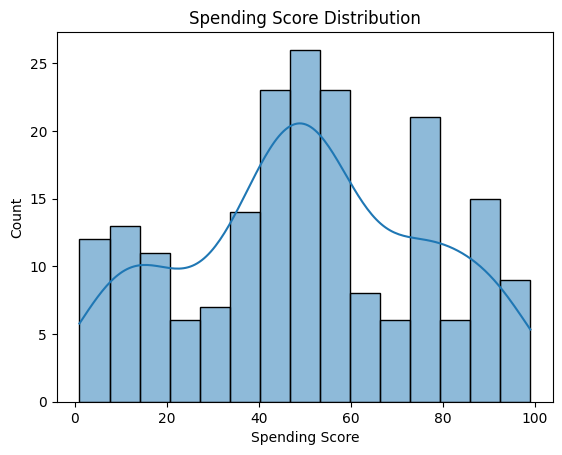

In [8]:
# Spending Score Distribution
sns.histplot(df_cleaned['Spending_Score'], bins=15, kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.show()




**📌 6. Pairplot & Correlation Analysis**

Visualize feature relationships and compute correlations.


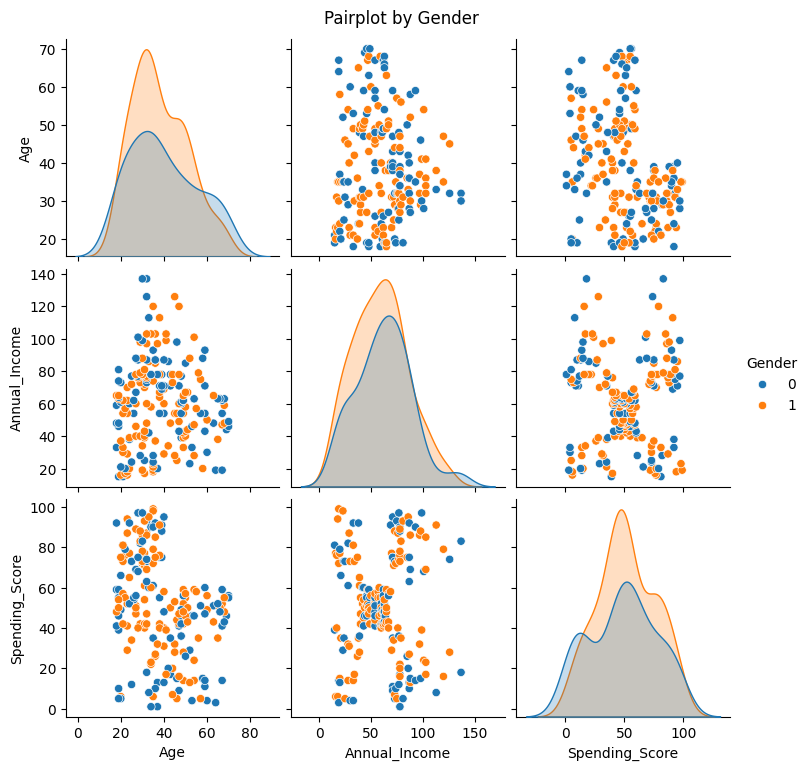

In [9]:
# Pairplot: Explore relationships
sns.pairplot(df_cleaned, hue='Gender')
plt.suptitle("Pairplot by Gender", y=1.02)
plt.show()



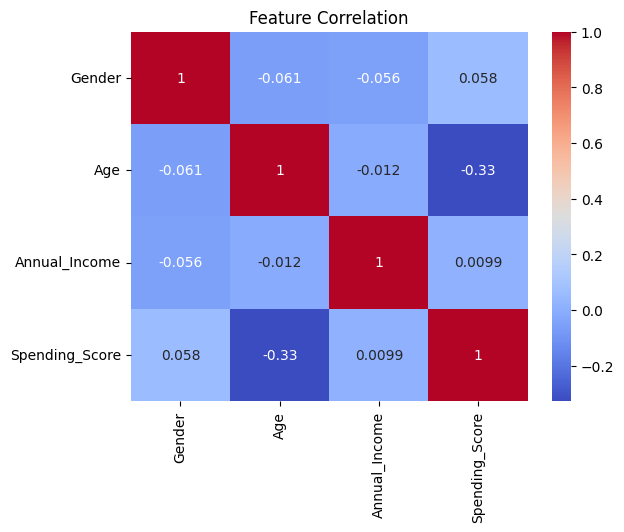

In [10]:
# Correlation heatmap
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**📌 7. Feature Scaling**

Standardize the dataset using `StandardScaler` for better clustering performance.


In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

# Check scaled result (optional)
scaled_data[:5]


array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992]])

**📌 8. K-Means Clustering & Elbow Method**

Find the optimal number of clusters using the Elbow Method and visualize WCSS.


WCSS values for different k:

k = 1 --> WCSS = 800.00
k = 2 --> WCSS = 597.95
k = 3 --> WCSS = 494.80
k = 4 --> WCSS = 395.39
k = 5 --> WCSS = 351.74
k = 6 --> WCSS = 277.39
k = 7 --> WCSS = 251.15
k = 8 --> WCSS = 211.99
k = 9 --> WCSS = 185.73
k = 10 --> WCSS = 152.03


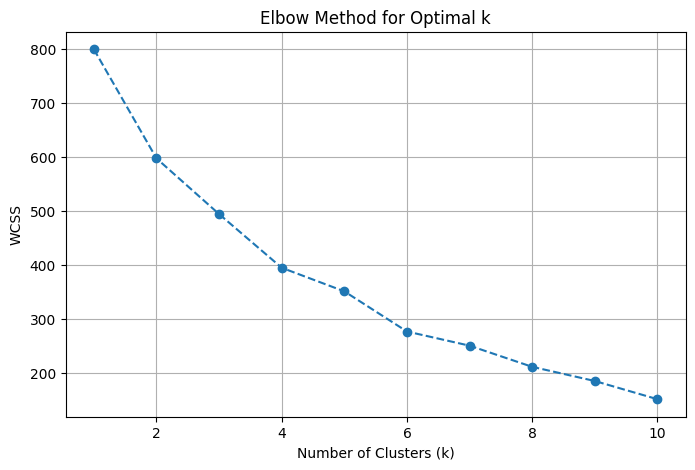

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

print("WCSS values for different k:\n")
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    inertia = kmeans.inertia_
    wcss.append(inertia)
    print(f"k = {i} --> WCSS = {inertia:.2f}")

# Elbow Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


| From k | To k            | WCSS Drop  |
| ------ | --------------- | ---------- |
| 1 → 2  | 800 → 597.95    | **202.05** |
| 2 → 3  | 597.95 → 494.80 | **103.15** |
| 3 → 4  | 494.80 → 395.39 | **99.41**  |
| 4 → 5  | 395.39 → 351.74 | **43.65**  |
| 5 → 6  | 351.74 → 277.39 | **74.35**  |
| 6 → 7  | 277.39 → 251.15 | **26.24**  |
| 7 → 8  | 251.15 → 211.99 | **39.16**  |
| 8 → 9  | 211.99 → 185.73 | **26.26**  |
| 9 → 10 | 185.73 → 152.03 | **33.70**  |


**📌 Interpretation:**

The biggest drop is from k = 1 to 4.

After k = 5, the decrease becomes less significant.

k = 5 seems like the “elbow” — the curve starts flattening afterward.

✅ **Final Decision: Use k = 5**

**📌 9. Apply Final KMeans Clustering**

Use optimal `k=5` clusters and assign cluster labels to the dataset.


In [14]:
# Final KMeans model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Assign clusters to the cleaned dataframe
df_cleaned['Cluster'] = clusters

# Also update the original dataframe for reference
df['Cluster'] = clusters

# Show first few entries with cluster label
df.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


**📌 10. PCA for 2D Cluster Visualization**

Apply Principal Component Analysis (PCA) to visualize customer segments in 2D space.


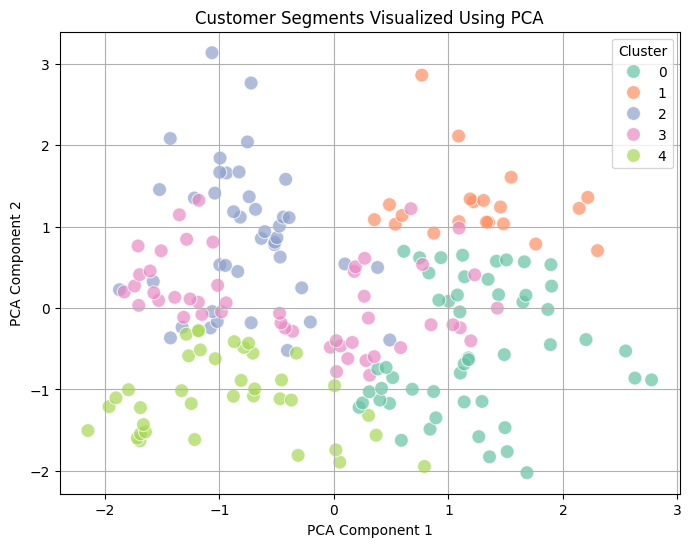

In [15]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100, alpha=0.7)
plt.title('Customer Segments Visualized Using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


We can analyze each cluster in textual form by summarizing the key characteristics (like average age, income, spending score) of each cluster. This helps you understand the customer segments in words, not just in a visual plot.

In [16]:
# Group by cluster and calculate mean values
cluster_summary = df_cleaned.groupby('Cluster').mean(numeric_only=True).round(2)
cluster_summary


,Gender,Age,Annual_Income,Spending_Score
Cluster,,,,
0,0.49,56.47,46.10,39.31
1,0.00,39.50,85.15,14.05
2,0.00,28.69,60.90,70.24
3,1.00,37.90,82.12,54.45
4,1.00,27.32,38.84,56.21



## 📊 **Cluster Profiles (Textual Form)**

### **🟦 Cluster 0** – **Older, Balanced Gender, Moderate Spend**

* 👥 **Gender**: Mixed (49% female, 51% male)
* 🎂 **Average Age**: 56.5 years (older customers)
* 💰 **Income**: \~\$46k
* 💳 **Spending Score**: 39.3

> 🔹 Likely cautious or budget-conscious older buyers.
> 🔹 Marketing Strategy: Offer value deals, senior perks, loyalty rewards.

---

### **🟥 Cluster 1** – **All Male, High Income, Very Low Spend**

* 👨 **Gender**: 100% Male
* 🎂 **Average Age**: 39.5 years
* 💰 **Income**: \~\$85k (highest)
* 💳 **Spending Score**: 14.0 (very low)

> 🔹 High earners but not active spenders. Possibly uninterested or skeptical.
> 🔹 Marketing Strategy: Target with premium, exclusive offerings, or trust-based campaigns.

---

### **🟩 Cluster 2** – **All Male, Young, Mid-Income, High Spend**

* 👨 **Gender**: 100% Male
* 🎂 **Average Age**: 28.7 years (young)
* 💰 **Income**: \~\$61k
* 💳 **Spending Score**: 70.2 (very high)

> 🔹 Young professionals who enjoy spending.
> 🔹 Marketing Strategy: Promote lifestyle products, trendy items, flash sales.

---

### **🟨 Cluster 3** – **All Female, Mid-Age, High Income, Moderate Spend**

* 👩 **Gender**: 100% Female
* 🎂 **Average Age**: 37.9 years
* 💰 **Income**: \~\$82k
* 💳 **Spending Score**: 54.4

> 🔹 Wealthy women with steady spending habits.
> 🔹 Marketing Strategy: Focus on brand loyalty, quality products, personalized offers.

---

### **🟪 Cluster 4** – **All Female, Youngest, Low Income, Moderate-High Spend**

* 👩 **Gender**: 100% Female
* 🎂 **Average Age**: 27.3 years (youngest group)
* 💰 **Income**: \~\$38.8k
* 💳 **Spending Score**: 56.2

> 🔹 Young shoppers with limited income but moderate spending.
> 🔹 Marketing Strategy: Focus on affordable luxury, student discounts, and seasonal campaigns.

---

## ✅ Summary Table

| Cluster | Gender | Age  | Income | Spend | Insight                        |
| ------- | ------ | ---- | ------ | ----- | ------------------------------ |
| 0       | Mixed  | 56.5 | 46k    | 39.3  | Cautious older buyers          |
| 1       | Male   | 39.5 | 85k    | 14.0  | High-income, low spend         |
| 2       | Male   | 28.7 | 61k    | 70.2  | Young, high-spending males     |
| 3       | Female | 37.9 | 82k    | 54.4  | Wealthy women, steady spenders |
| 4       | Female | 27.3 | 39k    | 56.2  | Young, budget-conscious women  |

---


**📌 11. Cluster Summary and Business Strategy**

Summarize clusters and suggest business strategies based on average features.


In [23]:
# Use your actual cluster_summary
cluster_summary = df_cleaned.groupby('Cluster').mean(numeric_only=True).round(2)

# Define insights and strategies based on your actual data
strategies = {
    0: {
        "Insight": "Older average earners with moderate spending",
        "Strategy": "Market health, retirement, or premium service products"
    },
    1: {
        "Insight": "High income but very low spending (price conscious or brand loyal)",
        "Strategy": "Introduce loyalty benefits or premium engagement programs"
    },
    2: {
        "Insight": "Young mid-income group with high spending",
        "Strategy": "Promote trend-based or personalized ads and offers"
    },
    3: {
        "Insight": "High income and moderate-to-high spending females",
        "Strategy": "Upsell luxury brands, tailor premium experiences"
    },
    4: {
        "Insight": "Young, lower-income, high spenders",
        "Strategy": "Push affordable trendy items, offer discounts & bundles"
    }
}

# Merge the insights and strategies into the actual cluster_summary
cluster_summary['Insight'] = cluster_summary.index.map(lambda i: strategies[i]['Insight'])
cluster_summary['Strategy'] = cluster_summary.index.map(lambda i: strategies[i]['Strategy'])

# Show the final interpretation table
print("\nCluster Interpretation and Suggested Marketing Strategies:\n")
print(cluster_summary)



Cluster Interpretation and Suggested Marketing Strategies:

         Gender    Age  Annual_Income  Spending_Score  \
Cluster                                                 
0          0.49  56.47          46.10           39.31   
1          0.00  39.50          85.15           14.05   
2          0.00  28.69          60.90           70.24   
3          1.00  37.90          82.12           54.45   
4          1.00  27.32          38.84           56.21   

                                                   Insight  \
Cluster                                                      
0             Older average earners with moderate spending   
1        High income but very low spending (price consc...   
2                Young mid-income group with high spending   
3        High income and moderate-to-high spending females   
4                       Young, lower-income, high spenders   

                                                  Strategy  
Cluster                                    

| Cluster | Gender | Age   | Income | Score | Insight                                      | Strategy                                               |
| ------: | ------ | ----- | ------ | ----- | -------------------------------------------- | ------------------------------------------------------ |
|       0 | Mixed  | 56.47 | 46.10  | 39.31 | Older average earners with moderate spending | Market health, retirement, or premium service products |
|       1 | Male   | 39.50 | 85.15  | 14.05 | High income but very low spending            | Loyalty benefits or exclusive offers                   |
|       2 | Female | 28.69 | 60.90  | 70.24 | Young, mid-income, high-spending group       | Trend-based personalized ads                           |
|       3 | Male   | 37.90 | 82.12  | 54.45 | High income, moderate-high spending          | Upsell luxury brands                                   |
|       4 | Male   | 27.32 | 38.84  | 56.21 | Young, low-income, high-spending             | Affordable bundles, discounts                          |


In [24]:
# Save the cluster interpretation and strategy table to CSV
cluster_summary.to_csv("cluster_summary_with_strategies.csv", index=True)


**📌 12. Cluster-wise Scatter Plot (Age vs Spending Score)**

Visualize customer segments using Age and Spending Score.


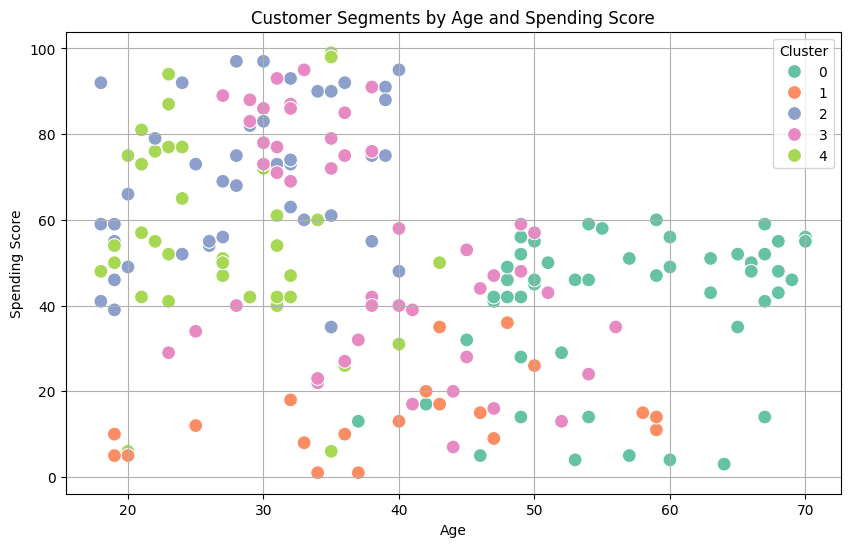

In [25]:

# Scatter plot: Age vs Spending Score by Cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned, x='Age', y='Spending_Score', hue='Cluster', palette='Set2', s=100)
plt.title('Customer Segments by Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


**📌 13. Silhouette Score Evaluation**

Evaluate clustering performance using the silhouette score.


In [34]:
from sklearn.metrics import silhouette_score

# Get number of clusters from fitted model
k = kmeans.n_clusters

# Calculate silhouette score
score = silhouette_score(scaled_data, clusters)
print(f"Silhouette Score for k={k}: {score:.2f}")


Silhouette Score for k=5: 0.27


**📌 13. t-SNE Visualization of Clusters**

Apply t-SNE to visualize clusters in a non-linear 2D space.



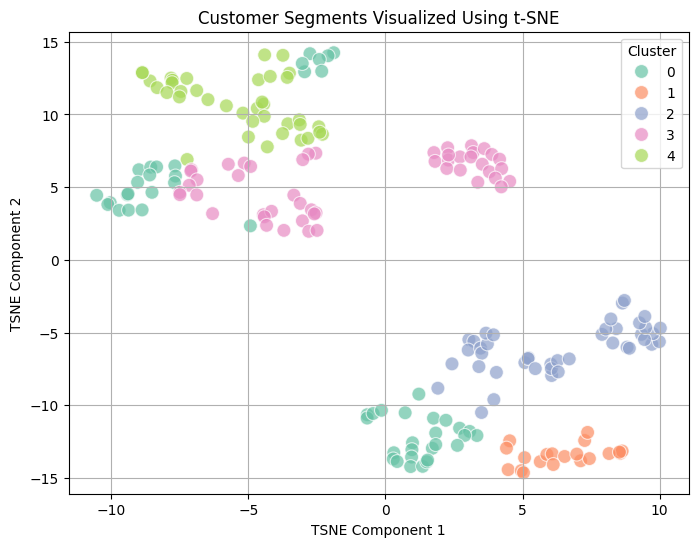

In [28]:
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(scaled_data)

# Create DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_result, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = clusters

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='Set2', s=100, alpha=0.7)
plt.title('Customer Segments Visualized Using t-SNE')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
